In [19]:
import numpy as np                                                                                                 
import pandas as pd                                                                                                
import matplotlib.pyplot as plt                                                                                    
import matplotlib.gridspec as gridspec                                                                             
from pathlib import Path                                                                                         

# ── Data loading ──────────────────────────────────────────────────────────────                                   
BASE = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")
                      
nonlinear_measure = "ipc_ipc_deg2_mean" # ipc_ipc_total_mean
                                                                                              
DATASETS = {             
    "GNM":            BASE / "hcp_schaefer_100_dataset/11_mst_2500_animal_0/all_metrics_for_11_mst_2500_animal_0_updated.csv",                                                                                        
    "MaMI":           BASE / "suarez_MaMI_dataset/05_mst_animal_0_compared_with_mami/metrics_2_computational.csv", 
    "diffusion":      BASE /                                                                                       
"kaysons_generated_networks_diffusion/05_mst_animal_0_compared_with_diffusion/metrics_2_computational.csv",        
    "propagation":    BASE /                                                                                       
"kaysons_generated_networks_propagation/05_mst_animal_0_compared_with_propagation/metrics_2_computational.csv",    
    "routing":        BASE /                                                                                     
"kaysons_generated_networks_routing/05_mst_animal_0_compared_with_routing/metrics_2_computational.csv",            
    "topology":       BASE /                                                                                     
"kaysons_generated_networks_topology/05_mst_animal_0_compared_with_topology/metrics_2_computational.csv",          
    "lexis_dev":      BASE /                                                                                     
"lexis_data_developing/05_mst_animal_0_compared_with_lexis_data_developing/metrics_2_computational.csv",           
    "lexis_consensus":BASE / "lexis_data_developing_consensus_per_age_1_year/00_pca/metrics_2_computational.csv",
}                                                                                                                  
                                                                                                                
dfs = {}                                                                                                           
for name, path in DATASETS.items():                       
    if path.exists():
        df = pd.read_csv(path)
        if nonlinear_measure in df.columns: # "ipc_ipc_total_mean" in df.columns:                                                                     
            dfs[name] = df     
        else: 
            print(f"Warning: {name} does not contain the nonlinear measure '{nonlinear_measure}' and will be skipped.")                                                                                    
                                                                                                                    
LAG_COLS   = [c for c in next(iter(dfs.values())).columns if c.startswith("ipc_ipc_linear_lag_")]                  
LAGS       = sorted([int(c.split("_")[-1]) for c in LAG_COLS])
COLORS     = plt.cm.tab10(np.linspace(0, 0.9, len(dfs)))                                                           
              

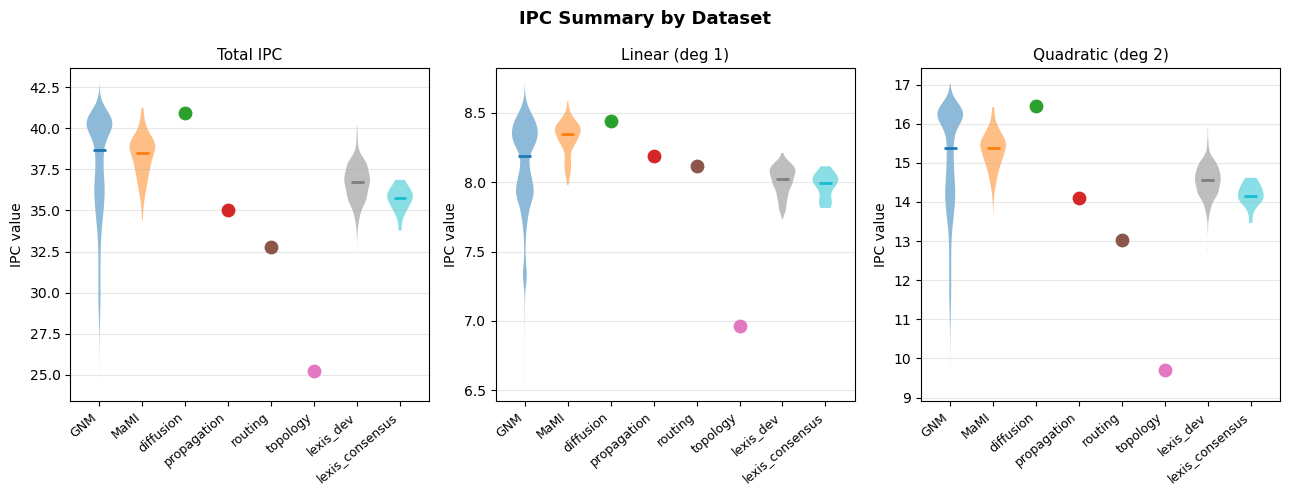

In [20]:
                                          
# ── Figure 1: IPC summary per dataset ────────────────────────────────────────                                    
#   For multi-network datasets: violin + median marker    
#   For single-network datasets: point only                                                                        
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=False)
SUMMARY_COLS = {                                                                                                   
    "ipc_ipc_total_mean":    "Total IPC",                                                                          
    "ipc_ipc_linear_mean":   "Linear (deg 1)",                                                                     
    # "ipc_ipc_nonlinear_mean":"Nonlinear (deg 2+3)",   
    "ipc_ipc_deg2_mean":     "Quadratic (deg 2)",                                                             
}                                                                                                                  
                                                                                                                    
for ax, (col, label) in zip(axes, SUMMARY_COLS.items()):                                                           
    names, positions = [], []                                                                                    
    for i, (name, df) in enumerate(dfs.items()):                                                                   
        vals = df[col].dropna().values
        pos  = i                                                                                                   
        if len(vals) > 1:                                                                                        
            parts = ax.violinplot(vals, positions=[pos], widths=0.6,                                               
                                showmedians=True, showextrema=False)                                             
            for pc in parts["bodies"]:                                                                             
                pc.set_facecolor(COLORS[i])                                                                        
                pc.set_alpha(0.5)                                                                                  
            parts["cmedians"].set_colors(COLORS[i])                                                                
            parts["cmedians"].set_linewidth(2)                                                                     
        else:                                                                                                      
            ax.scatter([pos], vals, color=COLORS[i], s=80, zorder=5)                                               
        names.append(name)                                                                                         
    ax.set_xticks(range(len(names)))                                                                               
    ax.set_xticklabels(names, rotation=40, ha="right", fontsize=9)                                                 
    ax.set_title(label, fontsize=11)                                                                               
    ax.set_ylabel("IPC value")                                                                                     
    ax.grid(axis="y", alpha=0.3)                                                                                   
                                                                                                                    
fig.suptitle("IPC Summary by Dataset", fontsize=13, fontweight="bold")                                             
fig.tight_layout()                                                                                                 
plt.savefig("ipc_summary.png", dpi=150, bbox_inches="tight")                                                       
plt.show()                                                                                                         


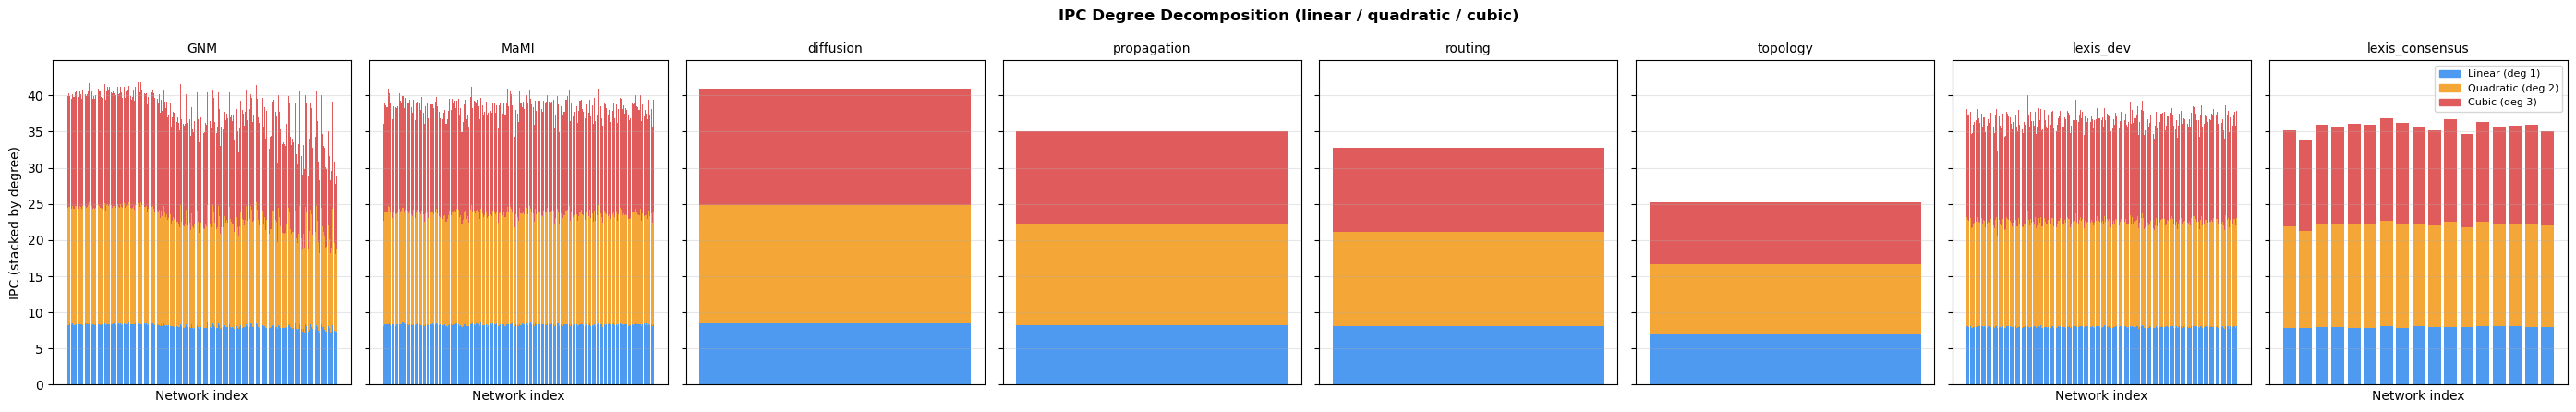

In [21]:

# ── Figure 2: Degree decomposition per dataset ────────────────────────────────                                   
#   Stacked bar: deg1 | deg2 | deg3, one bar per network (or just means)                                         
DEG_COLS   = ["ipc_ipc_deg1_mean", "ipc_ipc_deg2_mean", "ipc_ipc_deg3_mean"]                                       
DEG_LABELS = ["Linear (deg 1)", "Quadratic (deg 2)", "Cubic (deg 3)"]                                              
DEG_COLORS = ["#4e9af1", "#f4a636", "#e05c5c"]                                                                     
                                                                                                                    
n_datasets = len(dfs)                                                                                              
fig, axes = plt.subplots(1, n_datasets, figsize=(3.5 * n_datasets, 4.5), sharey=True)                              
if n_datasets == 1:                                                                                                
    axes = [axes]                                                                                                  
                                                                                                                    
for ax, (name, df), color in zip(axes, dfs.items(), COLORS):                                                       
    vals = df[DEG_COLS].dropna()                                                                                 
    x = np.arange(len(vals))                                                                                       
    bottom = np.zeros(len(vals))                                                                                 
    for dcol, dlabel, dcolor in zip(DEG_COLS, DEG_LABELS, DEG_COLORS):                                             
        ax.bar(x, vals[dcol], bottom=bottom, color=dcolor, label=dlabel, width=0.8)                                
        bottom += vals[dcol].values                                                                                
    ax.set_title(name, fontsize=10)                                                                                
    ax.set_xlabel("Network index" if len(vals) > 1 else "")                                                        
    ax.set_xticks([])                                                                                              
    ax.grid(axis="y", alpha=0.3)                                                                                   
                                                                                                                    
axes[0].set_ylabel("IPC (stacked by degree)")                                                                      
handles = [plt.Rectangle((0,0),1,1, color=c) for c in DEG_COLORS]                                                
axes[-1].legend(handles, DEG_LABELS, loc="upper right", fontsize=8)                                                
fig.suptitle("IPC Degree Decomposition (linear / quadratic / cubic)", fontsize=12, fontweight="bold")              
fig.tight_layout()                                                                                                 
plt.savefig("ipc_decomposition.png", dpi=150, bbox_inches="tight")                                                 
plt.show()                                                                                                         
           

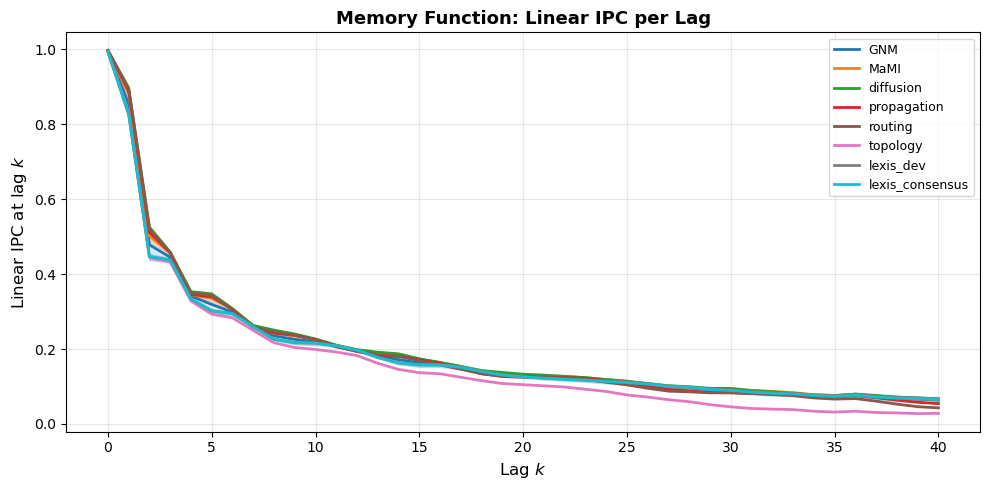

In [22]:
                                                                                                         
# ── Figure 3: Memory function (per-lag linear IPC) ───────────────────────────                                    
#   Mean ± std across networks, one line per dataset                                                               
fig, ax = plt.subplots(figsize=(10, 5))                                                                            
                                                                                                                    
for (name, df), color in zip(dfs.items(), COLORS):                                                                 
    lag_data = df[[f"ipc_ipc_linear_lag_{k}" for k in LAGS]].dropna()                                              
    mean_vals = lag_data.mean().values                                                                             
    std_vals  = lag_data.std().values                                                                              
    ax.plot(LAGS, mean_vals, color=color, label=name, lw=2)                                                        
    if len(lag_data) > 1:                                                                                          
        ax.fill_between(LAGS, mean_vals - std_vals, mean_vals + std_vals,                                          
                        color=color, alpha=0.15)       
        
                                                                                        
ax.set_xlabel("Lag $k$", fontsize=12)                                                                              
ax.set_ylabel("Linear IPC at lag $k$", fontsize=12)                                                                
ax.set_title("Memory Function: Linear IPC per Lag", fontsize=13, fontweight="bold")                                
ax.legend(fontsize=9)                                                                                              
ax.grid(alpha=0.3)                                                                                                 
fig.tight_layout()                                                                                                 
plt.savefig("ipc_memory_function.png", dpi=150, bbox_inches="tight")                                               
plt.show()                                                                                                         



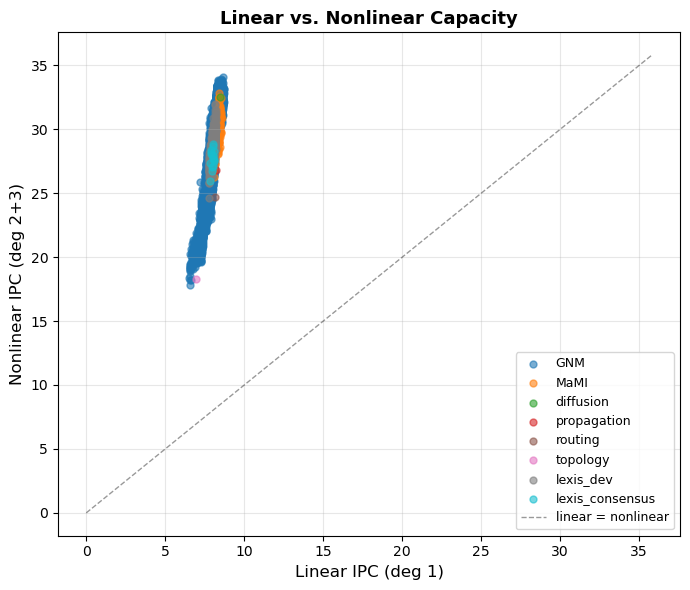

In [23]:

# ── Figure 4: Linear vs Nonlinear scatter ────────────────────────────────────                                    
fig, ax = plt.subplots(figsize=(7, 6))                                                                           
                                                                                                                    
for (name, df), color in zip(dfs.items(), COLORS):                                                                 
    lin  = df["ipc_ipc_linear_mean"].dropna().values                                                               
    nlin = df["ipc_ipc_nonlinear_mean"].dropna().values                                                            
    n    = min(len(lin), len(nlin))                                                                                
    ax.scatter(lin[:n], nlin[:n], color=color, alpha=0.6, s=25, label=name)                                        
                                                                                                                    
lim_max = max(                                                                                                     
    max(df["ipc_ipc_linear_mean"].max(), df["ipc_ipc_nonlinear_mean"].max())                                       
    for df in dfs.values()                                                                                         
) * 1.05
ax.plot([0, lim_max], [0, lim_max], "k--", lw=1, alpha=0.4, label="linear = nonlinear")                            
ax.set_xlabel("Linear IPC (deg 1)", fontsize=12)                                                                   
ax.set_ylabel("Nonlinear IPC (deg 2+3)", fontsize=12)
ax.set_title("Linear vs. Nonlinear Capacity", fontsize=13, fontweight="bold")                                      
ax.legend(fontsize=9)                                                                                            
ax.grid(alpha=0.3)                                                                                                 
fig.tight_layout()                                                                                                 
plt.savefig("ipc_linear_vs_nonlinear.png", dpi=150, bbox_inches="tight")                                           
plt.show()    

In [24]:
dfs["MaMI"]

for key in dfs["MaMI"].keys(): 
    if "ipc" in key: 
        print(key)
        
        
# "ipc_ipc_deg1_mean"
# "ipc_ipc_deg2_mean"

ipc_ipc_deg1_mean
ipc_ipc_deg1_std
ipc_ipc_deg2_mean
ipc_ipc_deg2_std
ipc_ipc_deg3_mean
ipc_ipc_deg3_std
ipc_ipc_linear_mean
ipc_ipc_nonlinear_mean
ipc_ipc_total_mean
ipc_ipc_total_std
ipc_ipc_linear_lag_0
ipc_ipc_linear_lag_1
ipc_ipc_linear_lag_2
ipc_ipc_linear_lag_3
ipc_ipc_linear_lag_4
ipc_ipc_linear_lag_5
ipc_ipc_linear_lag_6
ipc_ipc_linear_lag_7
ipc_ipc_linear_lag_8
ipc_ipc_linear_lag_9
ipc_ipc_linear_lag_10
ipc_ipc_linear_lag_11
ipc_ipc_linear_lag_12
ipc_ipc_linear_lag_13
ipc_ipc_linear_lag_14
ipc_ipc_linear_lag_15
ipc_ipc_linear_lag_16
ipc_ipc_linear_lag_17
ipc_ipc_linear_lag_18
ipc_ipc_linear_lag_19
ipc_ipc_linear_lag_20
ipc_ipc_linear_lag_21
ipc_ipc_linear_lag_22
ipc_ipc_linear_lag_23
ipc_ipc_linear_lag_24
ipc_ipc_linear_lag_25
ipc_ipc_linear_lag_26
ipc_ipc_linear_lag_27
ipc_ipc_linear_lag_28
ipc_ipc_linear_lag_29
ipc_ipc_linear_lag_30
ipc_ipc_linear_lag_31
ipc_ipc_linear_lag_32
ipc_ipc_linear_lag_33
ipc_ipc_linear_lag_34
ipc_ipc_linear_lag_35
ipc_ipc_linear_lag_36
ipc_ipc_lin

In [25]:
dfs.keys()

dict_keys(['GNM', 'MaMI', 'diffusion', 'propagation', 'routing', 'topology', 'lexis_dev', 'lexis_consensus'])